# Label Encoding 
Each catagorical data will be assigned a unique number  
This help us in processing the data
like for example we have three values 
Apple, Banana, Orange to make it easy to process we will assign them 0,1,2 now we can easily process the data

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
data_fram = pd.DataFrame({'Fruit': ['Apple', 'Banana', 'Cherry', 'Date','Apple', 'Date']})
label_encoder = LabelEncoder()
data_fram['Fruit_encoded'] = label_encoder.fit_transform(data_fram['Fruit'])
print(data_fram)

    Fruit  Fruit_encoded
0   Apple              0
1  Banana              1
2  Cherry              2
3    Date              3
4   Apple              0
5    Date              3


# Problem
Now here in this Label encoding we have an issue here a concept is built like 0>1>2>3 this comes automaticaly to mind but we actually do not want to do that so we then use one hot encoding


# One Hot Encoding
In one HOT encoding technique a matrix is created which contains only 0 and 1 and this is called one hot encoding
## Example
<!--MarkDown Table display of one hot encoding -->

| Fruit | Apple | Banana | Cherry | Date |
|------|-------|--------|--------|------|
| 0    | 1     | 0      | 0      | 0    |
| 1    | 0     | 1      | 0      | 0    |
| 2    | 0     | 0      | 1      | 0    |
| 3    | 0     | 0      | 0      | 1    |
| 4    | 1     | 0      | 0      | 0    |


In [2]:
df2 = pd.DataFrame(
    {
        'Height_cm': [150, 160, 170, 180, 190],
        'Weight_kg': [50, 60, 70, 80, 90]
    }
)

# Print origional data
print("Original Data:")
print(df2)
# Normalize the data using Min-Max Scaling
df2_normalized = (df2 - df2.min()) / (df2.max() - df2.min())

# Print normalized data 
print("\nNormalized Data:")
print(df2_normalized)

Original Data:
   Height_cm  Weight_kg
0        150         50
1        160         60
2        170         70
3        180         80
4        190         90

Normalized Data:
   Height_cm  Weight_kg
0       0.00       0.00
1       0.25       0.25
2       0.50       0.50
3       0.75       0.75
4       1.00       1.00


In [3]:
# Z Scoring

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df2_zscored = scaler.fit_transform(df2)
print(df2_zscored)

[[-1.41421356 -1.41421356]
 [-0.70710678 -0.70710678]
 [ 0.          0.        ]
 [ 0.70710678  0.70710678]
 [ 1.41421356  1.41421356]]


# Lab Tasks

## Lab Task 1
Load the Titanic dataset, display first 10 rows, column names, and data types

In [6]:
# Load the Titanic dataset, display first 10 rows, column names, and data types
import pandas as pd

titanic_data = pd.read_csv('D:\\2. Skill Development\\Machine-Learning\\datasets\\Titanic-Dataset.csv')
print('Titanic Dataset Loaded Successfully!')



Titanic Dataset Loaded Successfully!


In [7]:
print("First 10 Rows:")

# .head function is used to display the first n rows of the DataFrame, where n is specified as an argument (default is 5). In this case, it will display the first 10 rows of the titanic_data DataFrame.
print(titanic_data.head(10))



First 10 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timoth

In [8]:

print("\nColumn Names:")

print(titanic_data.columns.tolist())



Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [9]:

print("\nData Types:")
print(titanic_data.dtypes)


Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


## Lab Task 2
Check missing values in each column and decide whether to drop or impute

In [10]:
# Check missing values in each column and decide weather to drop or impute
missing_values = titanic_data.isnull().sum()

print(missing_values)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


| Column   | Missing | % Missing |
| -------- | ------- | --------- |
| Age      | 177     | ~20%      |
| Cabin    | 687     | ~77%      |
| Embarked | 2       | ~0.2%     |


## Decisions

### 1. Cabin → DROP

687 / 891 ≈ 77% missing

Too much missing data

Imputing would add noise


In [11]:
titanic_data.drop(columns=["Cabin"], inplace=True) # inplace=True means that the changes will be made directly to the original DataFrame, rather than creating a new one. After this line of code is executed, the "Cabin" column will be removed from the titanic_data DataFrame.

# Check missing values in each column and decide weather to drop or impute
missing_values = titanic_data.isnull().sum()

print(missing_values)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64


### 2. Age → IMPUTE

177 missing (~20%)

Important feature for survival

Do NOT drop column

Best practice: fill with median (robust to outliers)

In [12]:
titanic_data["Age"].fillna(titanic_data["Age"].median(), inplace=True)
# Print again to check if missing
print(titanic_data.isnull().sum())

# print first 10 ages to check if imputation worked
print(titanic_data["Age"].head(10))


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64
0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
6    54.0
7     2.0
8    27.0
9    14.0
Name: Age, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_17860\4142687844.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic_data["Age"].fillna(titanic_data["Age"].median(), inplace=True)


## Lab Task 3
Calculate mean, median, and mode of Age and Fare, compare and discuss

In [21]:
# Calculate mean, median, and mode of Age and Fare, compare and discuss

age_mean = titanic_data["Age"].mean()
age_median = titanic_data["Age"].median()
age_mode = titanic_data["Age"].mode()

fare_mean = titanic_data["Fare"].mean()
fare_median = titanic_data["Fare"].median()
fare_mode = titanic_data["Fare"].mode()

print("Mean of Age:", age_mean)
print("Median of Age:", age_median)
print("Mode of Age:", age_mode)

print("Mean of Fare:", fare_mean)  
print("Median of Fare:", fare_median)
print("Mode of Fare:", fare_mode)

Mean of Age: 29.36158249158249
Median of Age: 28.0
Mode of Age: 0    28.0
Name: Age, dtype: float64
Mean of Fare: 32.204207968574636
Median of Fare: 14.4542
Mode of Fare: 0    8.05
Name: Fare, dtype: float64


## Lab Task 4
Plot histograms of Age and Fare and comment on the distribution shape

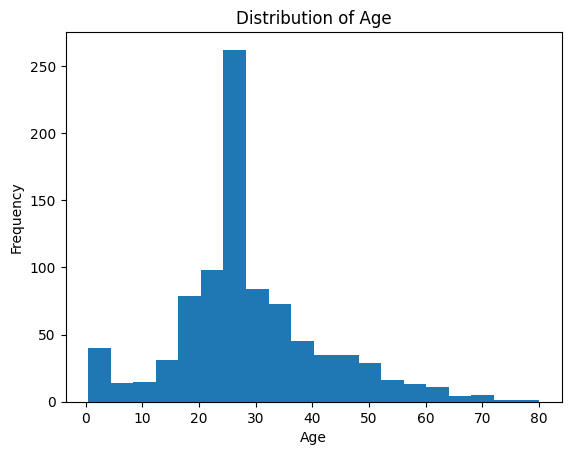

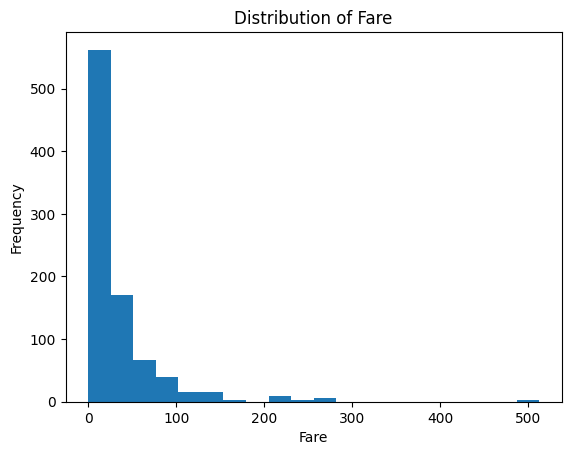

In [23]:
# Plot histograms of Age and Fare and comment on the distribution shape
import matplotlib.pyplot as plt

plt.hist(titanic_data["Age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()

plt.hist(titanic_data["Fare"], bins=20)
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.title("Distribution of Fare")
plt.show()

## Lab Task 5
Apply label encoding on gender column and show dataset before and after encoding

In [31]:
# Apply label encoding on gender column and show dataset before and after encoding
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
# before encoding the sex coloumn
print("Before Label Encoding:")
print(titanic_data["Sex"].head(4))

titanic_data["Sex_encoded"] = label_encoder.fit_transform(titanic_data["Sex"])
print("\nAfter Label Encoding:")
print(titanic_data["Sex_encoded"].head(4))





Before Label Encoding:
0      male
1    female
2    female
3    female
Name: Sex, dtype: object

After Label Encoding:
0    1
1    0
2    0
3    0
Name: Sex_encoded, dtype: int64


## Lab Task 6
Apply one-hot encoding on Embarked column, create dummy variables, and drop one to avoid redundancy

In [39]:
# Apply one-hot encoding on Embarked column, create dummy variables, and drop one to avoid redundancy

# get-dummies mean one-hot encoding

titanic_data = pd.get_dummies(titanic_data, columns=["Embarked"], drop_first=True)
#print embarked coloum only
print(titanic_data[["Embarked_Q", "Embarked_S"]].head(10))

   Embarked_Q  Embarked_S
0       False        True
1       False       False
2       False        True
3       False        True
4       False        True
5        True       False
6       False        True
7       False        True
8       False        True
9       False       False


## Lab Task 7
Compute correlation matrix for Age, Fare, Pclass, and Survived and visualize with a heatmap

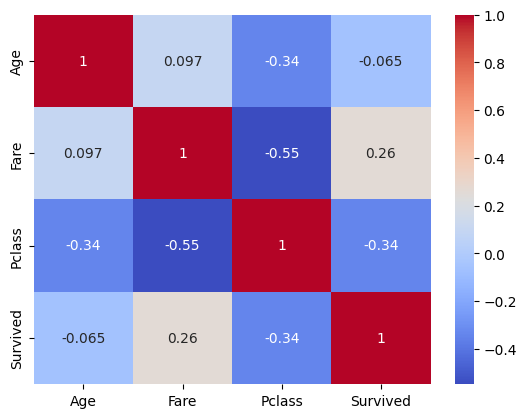

In [41]:
# Compute correlation matrix for Age, Fare, Pclass, and Survived and visualize with a heatmap
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = titanic_data[["Age", "Fare", "Pclass", "Survived"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.show()

Mean of scaled Fare: 0.06285842768394742
Standard deviation of scaled Fare: 0.0969406671428724


Text(0.5, 0, 'Fare')

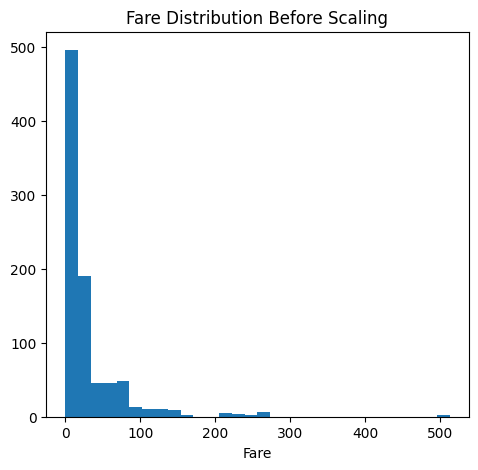

In [45]:
# Apply Min-Max scaling on Fare, compare original vs scaled values, and plot both distributions
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_fare = scaler.fit_transform(titanic_data[["Fare"]])
print("Mean of scaled Fare:", scaled_fare.mean())
print("Standard deviation of scaled Fare:", scaled_fare.std())

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(titanic_data["Fare"], bins=30)
plt.title("Fare Distribution Before Scaling")
plt.xlabel("Fare")

Mean of scaled Age: 2.272779794518839e-16
Standard deviation of scaled Age: 1.0


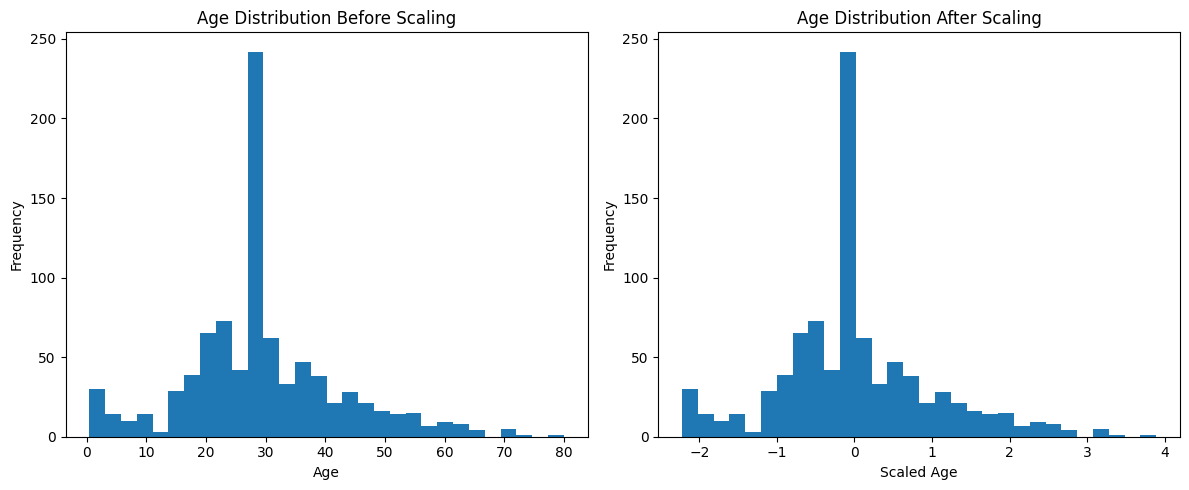

In [44]:
# Apply StandardScaler on Age, verify mean ≈ 0 and standard deviation ≈ 1, and plot distributions before and after scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_age = scaler.fit_transform(titanic_data[["Age"]])
print("Mean of scaled Age:", scaled_age.mean())
print("Standard deviation of scaled Age:", scaled_age.std())

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(titanic_data["Age"], bins=30)
plt.title("Age Distribution Before Scaling")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(scaled_age.flatten(), bins=30)
plt.title("Age Distribution After Scaling")
plt.xlabel("Scaled Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()